# MC simulations of structural transitions in a 2D system

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from tqdm import tqdm
import pickle
from numba import njit

### Workflow

- model particles
- create configuration 
- MC algorithm:
    1. Randomly select a particle m, with coordinate rm.
    2. Make a trial displacement, to an attempted coordinate rn: rn = rm + ∆∆∆, where ∆∆∆ is a
    random vector, usually constrained within some limits (see below).(xn = xm + ∆(ξx − 0.5)
yn = ym + ∆(ξy − 0.5))
    3. Calculate ∆U ≡ Un(r′N ; rn) − Um(rN ; rm).
        - Get distance between particles
        - Lennard Jones Potential: (r) = 4ϵ[( σ/r )12 − ( σ/r )6] 
    4. Accept the move if ξ < e−β∆U , where ξ is a random number (0 < ξ < 1), else retain the
    “old” coordinate. Note that a new random number has to be produced each time, i.e. ξ
    does not indicate a fixed number. If the move is accepted, update the coordinate for particle
    m, rm => rn, as well as the total energy (new energy: Un(r′N ; rn) = Um(rN ; rm) + ∆U ).
    5. Occasionally, i.e. with some chosen (usually low) frequency, sample averages.
    6. If the number of cycles is less than a chosen maximum, go back to entry 1; otherwise
    the simulation is finished, whereby averages are printed to some log file, and the final
    coordinates are saved on disk
- run until equilibrium is reached




In [ ]:
from numba import njit

@njit
def rdf_numba(pos, L, dr, rmax):
    N = pos.shape[0]
    nbins = int(rmax / dr)
    counts = np.zeros(nbins)

    for i in range(N - 1):
        for j in range(i + 1, N):
            dx = pos[i, 0] - pos[j, 0]
            dy = pos[i, 1] - pos[j, 1]

            dx -= L * np.rint(dx / L)
            dy -= L * np.rint(dy / L)

            r = np.sqrt(dx*dx + dy*dy)

            if r < rmax:
                counts[int(r / dr)] += 2.0

    return counts

 def sample_rdf(self):
        counts = rdf_numba(
            self.pos, self.LENGTH,
            self.rdf_dr, self.rdf_rmax
        )

        r = (np.arange(len(counts)) + 0.5) * self.rdf_dr
        shell_area = 2.0 * np.pi * r * self.rdf_dr
        nb = self.N / self.LENGTH**2

        self.rdf_counts += counts / self.N / shell_area / nb
        self.rdf_samples += 1

        return r, self.rdf_counts / self.rdf_samples


In [6]:
@njit
def calc_U_1_particle(con, p_idx, p_new, LENGTH,
                      sigma_0, sigma_1, epsilon):

    U = 0.0

    for j in range(len(con)):
        if j == p_idx:
            continue

        dx = con[j, 0] - p_new[0]
        dy = con[j, 1] - p_new[1]

        dx -= np.rint(dx / LENGTH) * LENGTH
        dy -= np.rint(dy / LENGTH) * LENGTH

        r2 = dx*dx + dy*dy

        if r2 < sigma_0**2:
            return np.inf

        if r2 < sigma_1**2:
            U += epsilon

    return U

In [7]:
class Particles_2D():
    # sigma_0 = 1: bounding box abgeleitet davon und von ρ∗ ≡ N σ20 /L2

    def __init__(self,N,delta_step=0.5,sigma_0=1,epsilon=1.0,o=0.1):
        self.delta_step = delta_step
        self.sigma_0 = sigma_0 # define sigma_0 as our unit of length? --> create bounding box from it?
        self.sigma_1 = 2.5*sigma_0
        self.epsilon = epsilon
        self.N = N
        # sigma_0 = 1: bounding box abgeleitet davon und von ρ∗ ≡ N σ20 /L2 --> L = sqrt(N/o)
        self.LENGTH = np.sqrt(N/o)
        self.bounding_box =(self.LENGTH,self.LENGTH)
        self.con = np.random.uniform(0, self.LENGTH, size=(N, 2))
        self.energies = []
        self.rdf_dr = 0.05 * self.sigma_0
        self.rdf_rmax = self.LENGTH / 2
        self.rdf_counts = np.zeros(int(self.rdf_rmax / self.rdf_dr))
        self.rdf_samples = 0

    def initialize_grid(self):

        n_side = int(np.ceil(np.sqrt(self.N)))

        spacing = self.LENGTH / n_side

        x = np.arange(n_side) * spacing + spacing / 2
        y = np.arange(n_side) * spacing + spacing / 2

        xx, yy = np.meshgrid(x, y)

        positions = np.column_stack((xx.ravel(), yy.ravel()))

        self.con = positions[:self.N]

   
    # def calc_U_1_particle(self, p_idx, p_new):
    #     dist = self.con - p_new

    #     # Ignore particle itself
    #     dist[p_idx] = 0.0

    #     dist -= np.round(dist / self.LENGTH) * self.LENGTH

    #     r2 = np.sum(dist**2, axis=1)

    #     # phi = np.where(
    #             #     r < self.sigma_0**2,
    #             #     np.inf,
    #             #     np.where(r < self.sigma_1**2, self.epsilon, 0)
    #             # )
    #             # u = np.sum(phi)
        

    #     if np.any((r2 < self.sigma_0**2) & (r2 > 0)):
    #         return np.inf

    #     return self.epsilon * np.count_nonzero(
    #         (r2 < self.sigma_1**2) & (r2 > 0)
    #     )
    
    def calc_U(self):

        total_pairs = 0

        for i in range(self.N - 1):

            dx = self.con[i, 0] - self.con[i + 1:, 0]
            dy = self.con[i, 1] - self.con[i + 1:, 1]

            # PBC
            dx -= self.LENGTH * np.round(dx / self.LENGTH)
            dy -= self.LENGTH * np.round(dy / self.LENGTH)

            # Squared distances
            r2 = dx**2 + dy**2

            # Any overlap?
            if np.any(r2 < self.sigma_0**2):
                return np.inf

            # Count interacting pairs
            total_pairs += np.count_nonzero(
                r2 < self.sigma_1**2
            )

        return self.epsilon * total_pairs

            
        #     phi = np.where(
        #         r < self.sigma_0,
        #         np.inf,
        #         np.where(r < self.sigma_1, self.epsilon, 0.0)
        #     )

        #     # Add energy
        #     u += np.sum(phi)

        # return u

    def calc_new_pos(self,p):
        xi_rv = np.random.sample(2)
        p_new = p + self.delta_step*(xi_rv - 0.5) # add: box restriction
        p_new %= self.LENGTH
        return p_new
    
    def count_overlaps(self):
        overlaps = 0

        for i in range(self.N):
            for j in range(i + 1, self.N):

                dr = self.con[i] - self.con[j]
                r = np.linalg.norm(dr)

                if r < self.sigma_0:
                    overlaps += 1

        return overlaps
    

    def save(self,path):
        pass

    # def initialize_energy(self):
    #     """
    #     Calculate the initial total energy and the interaction count
    #     for every particle.

    #     self.local_energy[i] = energy contribution of particle i
    #     with all other particles.

    #     Since every pair is counted twice in local_energy,
    #     total energy = 0.5 * sum(local_energy).
    #     """

    #     self.local_energy = np.zeros(self.N, dtype=np.float64)

    #     for i in range(self.N - 1):

    #         dx = self.con[i, 0] - self.con[i + 1:, 0]
    #         dy = self.con[i, 1] - self.con[i + 1:, 1]

    #         # PBC
    #         dx -= self.LENGTH * np.round(dx / self.LENGTH)
    #         dy -= self.LENGTH * np.round(dy / self.LENGTH)

    #         r2 = dx * dx + dy * dy

    #         # Hard-core overlap
    #         if np.any(r2 < self.sigma_0**2):
    #             self.local_energy[:] = np.inf
    #             return np.inf

    #         # Number of interacting particles
    #         interacting = r2 < self.sigma_1**2

    #         n_interacting = np.count_nonzero(interacting)

    #         self.local_energy[i] += self.epsilon * n_interacting

    #         self.local_energy[i + 1:] += (
    #             self.epsilon * interacting
    #         )

    #     return 0.5 * np.sum(self.local_energy)

    def average_sum(self):
        block_averages = np.asarray(
            self.block_averages,
            dtype=np.float64
        )

        mean_U = np.mean(block_averages)
        variance_blocks = np.var(block_averages)

        return block_averages, variance_blocks
    
    def run_mc(self,max_iter,T=0.1,hotstart=False,cal_delta=False,grid_init=False,prod=False,block_size=1000):
        if grid_init:
            self.initialize_grid()
    
        print("Overlaps start:", self.count_overlaps())
        accept = 0
        self.block_size = block_size
        #β = 1/(kB T ), where kB is Boltzmann’s constant. 
                # T* = kT /ϵ = 0.1 --> β = 1/(T*ϵ)
        self.beta = 1/(T*self.epsilon)
        
        # calculate U once for all particles
        # if hotstart:
        #     U_sum = self.initialize_energy()
      
        U_sum = self.calc_U()
        accept_loc = 0

        block_sum = 0.0
        block_count = 0
        self.block_averages = []


        for i in tqdm(range(max_iter)):

            
            # 1. Randomly select a particle m, with coordinate rm.
            p_idx = np.random.randint(self.N)
            p = self.con[p_idx] #random particle with coordinates in p

            # 2. Make a trial displacement, to an attempted coordinate rn: rn = rm + ∆∆∆, where ∆∆∆ is a random vector
            p_new = self.calc_new_pos(p)      
            # 3. Calculate ∆U ≡ Un(r′N ; rn) − Um(rN ; rm).
            U_m = calc_U_1_particle(self.con,p_idx,p,self.LENGTH,self.sigma_0,self.sigma_1,epsilon=self.epsilon)
            U_n = calc_U_1_particle(self.con,p_idx,p_new,self.LENGTH,self.sigma_0,self.sigma_1,epsilon=self.epsilon)
            #U_m = self.calc_U_1_particle(p_idx,p) 
            #U_n = self.calc_U_1_particle(p_idx,p_new)
            
            if np.isinf(U_m):
                if np.isinf(U_n):
                    pass
                else:
                    self.con[p_idx] = p_new
                    accept += 1
                    accept_loc += 1
            else:

                delta_U = U_n - U_m

                if delta_U <= 0:
                    accept_run = True
                else:
                    accept_run = np.random.random() < np.exp(-self.beta * delta_U)
                # 4. Accept the move if ξ < e−β∆U , where ξ is a random number (0 < ξ < 1), else retain the “old” coordinate.

                if accept_run:
                    accept += 1
                    accept_loc += 1
                    self.con[p_idx] = p_new
                    #self.local_energy[p_idx] = U_n
                    # new energy: Un(r′N ; rn) = Um(rN ; rm) + ∆U 
                    U_sum += delta_U

            if cal_delta and i % 500 == 0 and i > 0:

                ratio = accept_loc / 500

                if ratio > 0.7:
                    self.delta_step *= 1.1

                elif ratio < 0.25:
                    self.delta_step *= 0.9
                self.delta_step = min(self.delta_step, self.LENGTH)
                accept_loc = 0

            

            if i % 1000000 == 0 and i > 0:
                U_sum = self.calc_U()

            if not hotstart:
                block_sum += U_sum
                block_count += 1

                
                if block_count == block_size:
                    block_average = (
                        block_sum / block_size
                    )

                    self.block_averages.append(
                        block_average
                    )

                    # Reset block
                    block_sum = 0.0
                    block_count = 0


            if hotstart and i % 100000 == 0 and i > 0:
                U_sum = self.calc_U()
                ratio = accept/(i + 1)
                print(ratio)
                #print("Overlaps:", self.count_overlaps())

                if not np.isinf(U_sum):
                    print("ratio: ",ratio )
                    print("Overlaps end: ",self.count_overlaps())
                    print("delta_step: ",self.delta_step)
                    return
        
            if prod and i > 0 and i % 100000 == 0:
                #implement density function
                pass



        # 30 -70% acceptance rate (choose delta accordingly)
        # 5. Occasionally, i.e. with some chosen (usually low) frequency, sample averages.

        # 6. If the number of cycles is less than a chosen maximum, go back to entry 1; otherwise
        # the simulation is finished, whereby averages are printed to some log file, and the final
        # coordinates are saved on disk
        ratio = accept/max_iter
        print("ratio: ",ratio )
        print("Overlaps end: ",self.count_overlaps())
        print("delta_step: ",self.delta_step)
        

        

# Temperature Workflow

Overlaps start: 42


  5%|▌         | 100000/2000000 [00:01<00:34, 55066.48it/s]


0.5350046499535005
ratio:  0.5350046499535005
Overlaps end:  0
delta_step:  2
Starting equilibrium run at Temperature 0.25
Overlaps start: 0


100%|██████████| 2000000/2000000 [00:34<00:00, 57231.31it/s]


ratio:  0.3712365
Overlaps end:  0
delta_step:  0.45753584909922024


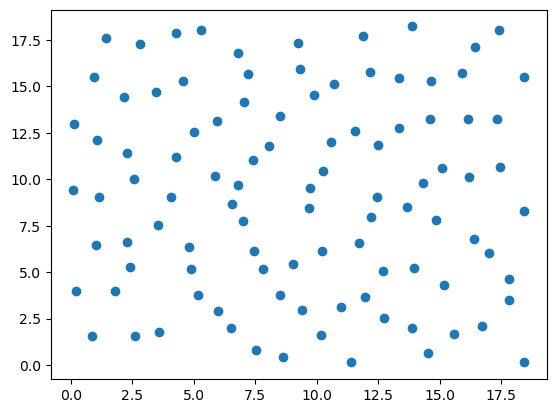

Starting production run at Temperature 0.25
Overlaps start: 0


100%|██████████| 20000000/20000000 [05:47<00:00, 57603.16it/s]


ratio:  0.3758482
Overlaps end:  0
delta_step:  0.45753584909922024


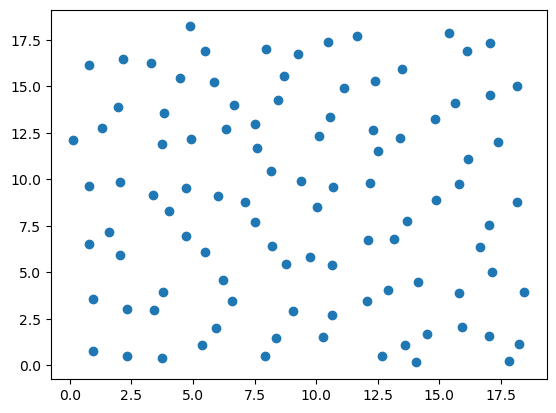

Starting equilibrium run at Temperature 0.24
Overlaps start: 0


100%|██████████| 2000000/2000000 [00:38<00:00, 52062.84it/s]


ratio:  0.364846
Overlaps end:  0
delta_step:  0.45753584909922024


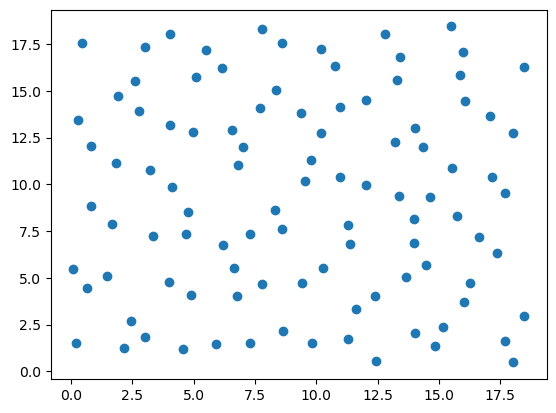

Starting production run at Temperature 0.24
Overlaps start: 0


100%|██████████| 20000000/20000000 [06:56<00:00, 48031.71it/s]


ratio:  0.36333555
Overlaps end:  0
delta_step:  0.45753584909922024


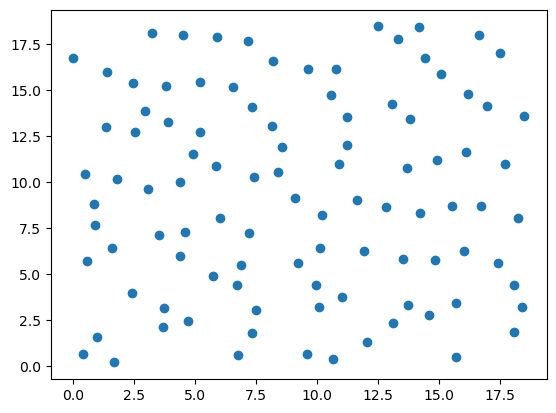

Starting equilibrium run at Temperature 0.23
Overlaps start: 0


100%|██████████| 2000000/2000000 [00:39<00:00, 50366.51it/s]


ratio:  0.3749745
Overlaps end:  0
delta_step:  0.4117822641892982


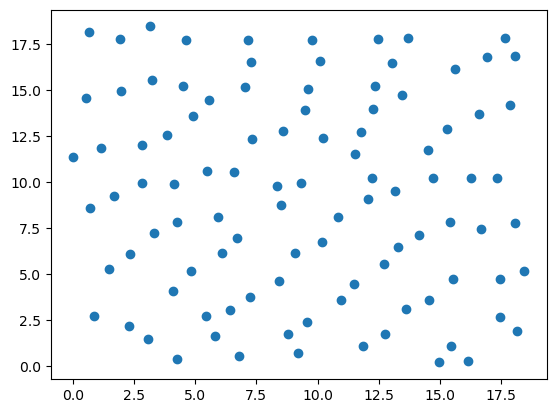

Starting production run at Temperature 0.23
Overlaps start: 0


100%|██████████| 20000000/20000000 [07:55<00:00, 42086.14it/s]


ratio:  0.3833939
Overlaps end:  0
delta_step:  0.4117822641892982


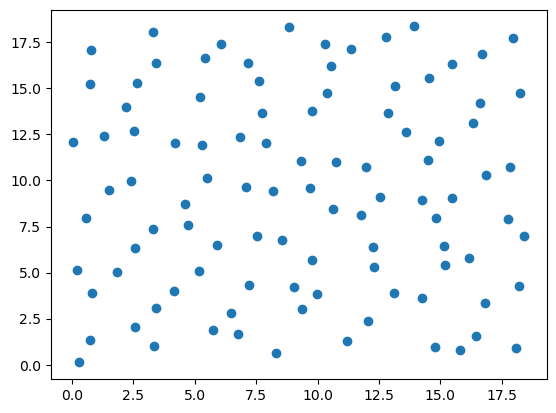

Starting equilibrium run at Temperature 0.22
Overlaps start: 0


100%|██████████| 2000000/2000000 [00:53<00:00, 37398.69it/s]


ratio:  0.4009065
Overlaps end:  0
delta_step:  0.3706040377703684


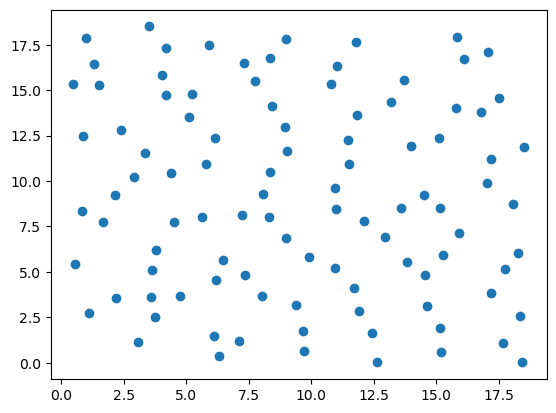

Starting production run at Temperature 0.22
Overlaps start: 0


100%|██████████| 20000000/20000000 [09:23<00:00, 35475.44it/s]


ratio:  0.40626805
Overlaps end:  0
delta_step:  0.3706040377703684


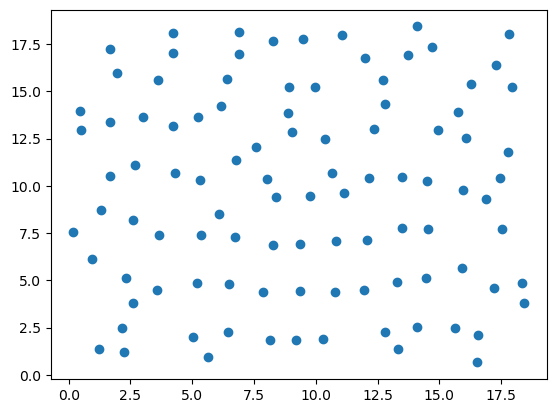

Starting equilibrium run at Temperature 0.21
Overlaps start: 0


100%|██████████| 2000000/2000000 [01:04<00:00, 30957.84it/s]


ratio:  0.3916905
Overlaps end:  0
delta_step:  0.3706040377703684


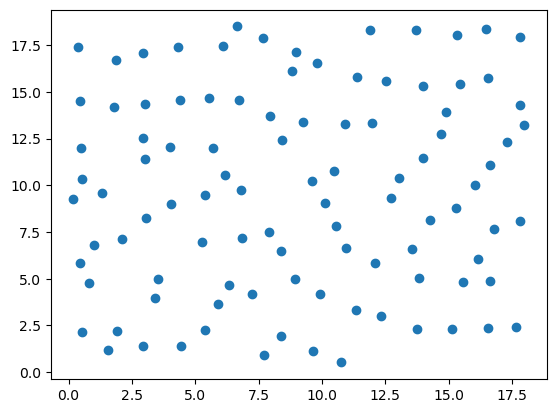

Starting production run at Temperature 0.21
Overlaps start: 0


100%|██████████| 20000000/20000000 [10:51<00:00, 30682.47it/s]


ratio:  0.3880878
Overlaps end:  0
delta_step:  0.3706040377703684


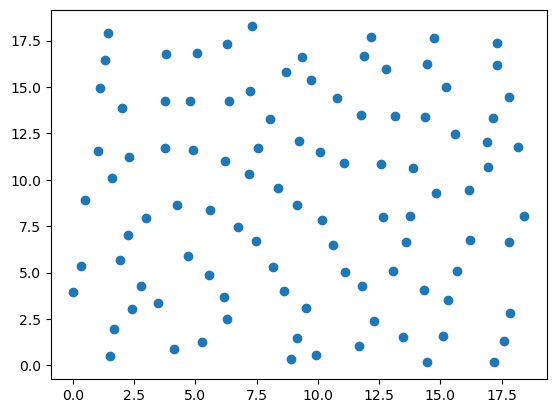

Starting equilibrium run at Temperature 0.2
Overlaps start: 0


100%|██████████| 2000000/2000000 [01:05<00:00, 30698.27it/s]


ratio:  0.3777655
Overlaps end:  0
delta_step:  0.3706040377703684


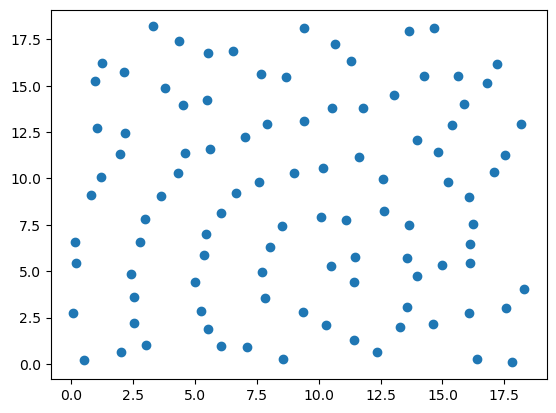

Starting production run at Temperature 0.2
Overlaps start: 0


100%|██████████| 20000000/20000000 [08:26<00:00, 39453.28it/s]


ratio:  0.37783525
Overlaps end:  0
delta_step:  0.3706040377703684


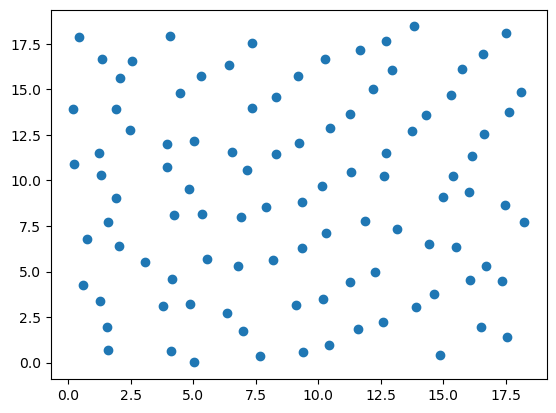

Starting equilibrium run at Temperature 0.19
Overlaps start: 0


100%|██████████| 2000000/2000000 [00:37<00:00, 53111.20it/s]


ratio:  0.3618235
Overlaps end:  0
delta_step:  0.3706040377703684


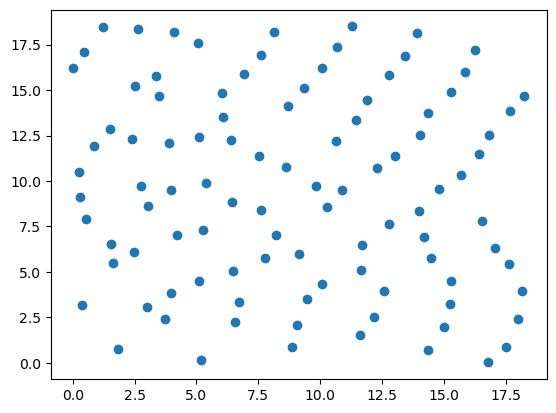

Starting production run at Temperature 0.19
Overlaps start: 0


100%|██████████| 20000000/20000000 [06:26<00:00, 51735.28it/s]


ratio:  0.343783
Overlaps end:  0
delta_step:  0.3706040377703684


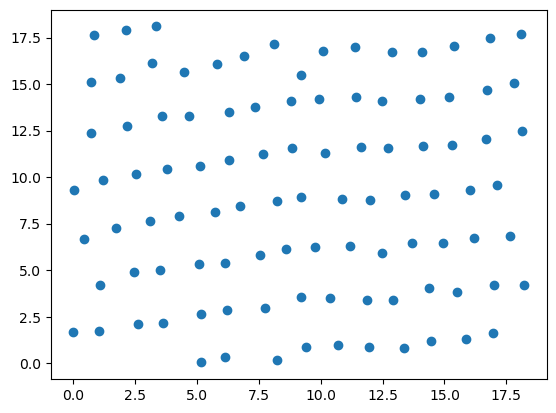

Starting equilibrium run at Temperature 0.18
Overlaps start: 0


100%|██████████| 2000000/2000000 [00:40<00:00, 49119.00it/s]


ratio:  0.372013
Overlaps end:  0
delta_step:  0.3001892705939984


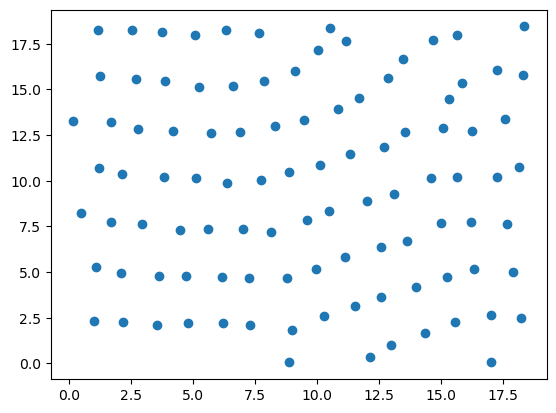

Starting production run at Temperature 0.18
Overlaps start: 0


100%|██████████| 20000000/20000000 [06:30<00:00, 51260.71it/s]


ratio:  0.39162195
Overlaps end:  0
delta_step:  0.3001892705939984


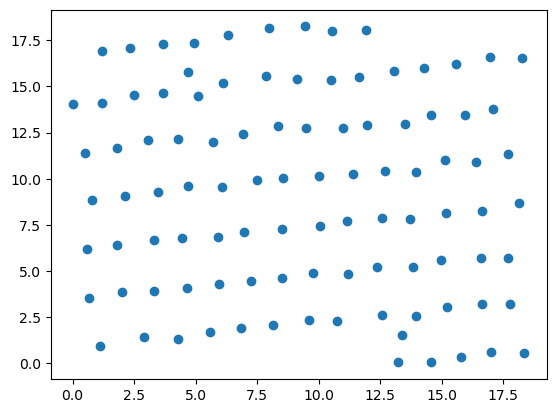

Starting equilibrium run at Temperature 0.17
Overlaps start: 0


100%|██████████| 2000000/2000000 [00:37<00:00, 52862.49it/s]


ratio:  0.388793
Overlaps end:  0
delta_step:  0.3001892705939984


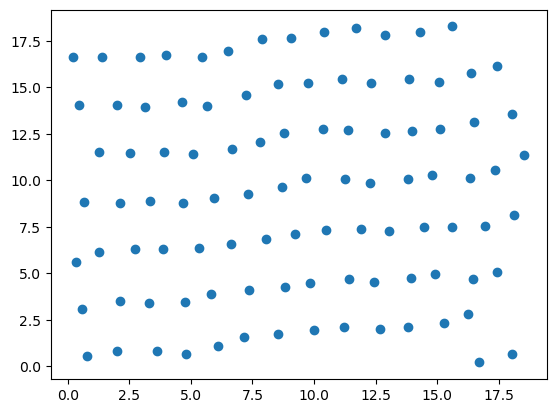

Starting production run at Temperature 0.17
Overlaps start: 0


100%|██████████| 20000000/20000000 [06:11<00:00, 53811.82it/s]


ratio:  0.3845291
Overlaps end:  0
delta_step:  0.3001892705939984


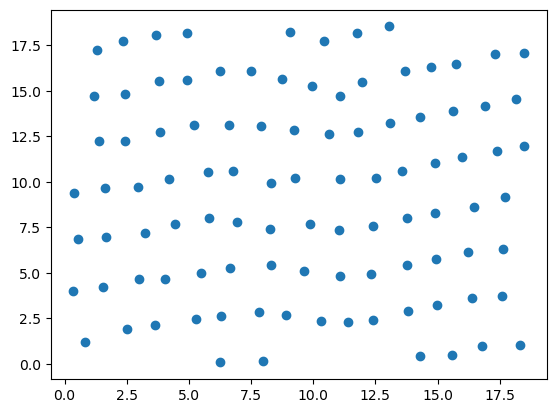

Starting equilibrium run at Temperature 0.16
Overlaps start: 0


100%|██████████| 2000000/2000000 [00:37<00:00, 52933.43it/s]


ratio:  0.390472
Overlaps end:  0
delta_step:  0.3001892705939984


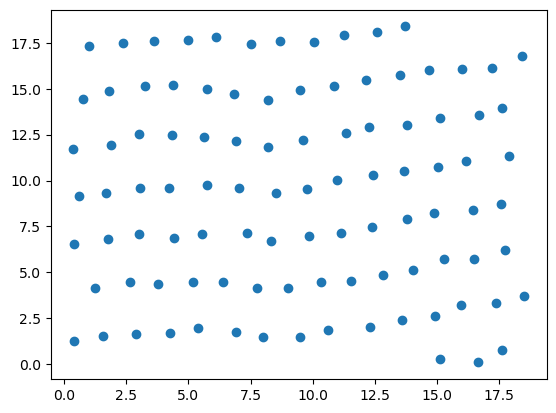

Starting production run at Temperature 0.16
Overlaps start: 0


100%|██████████| 20000000/20000000 [06:05<00:00, 54772.40it/s]


ratio:  0.3744323
Overlaps end:  0
delta_step:  0.3001892705939984


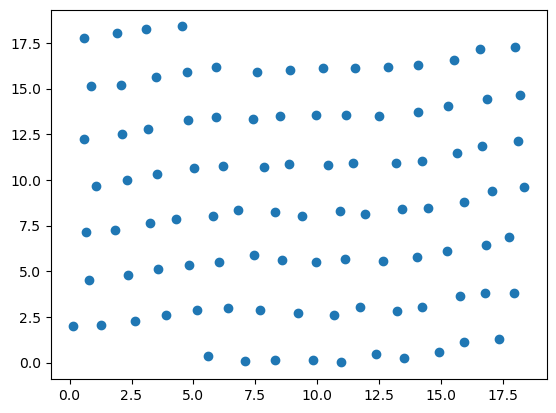

Starting equilibrium run at Temperature 0.15
Overlaps start: 0


100%|██████████| 2000000/2000000 [00:37<00:00, 53167.56it/s]


ratio:  0.370897
Overlaps end:  0
delta_step:  0.3001892705939984


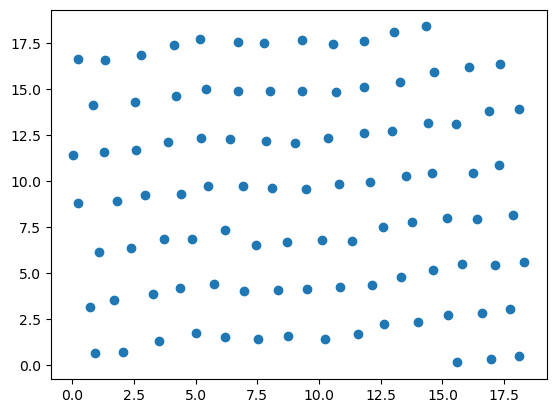

Starting production run at Temperature 0.15
Overlaps start: 0


100%|██████████| 20000000/20000000 [06:13<00:00, 53486.85it/s]


ratio:  0.37017115
Overlaps end:  0
delta_step:  0.3001892705939984


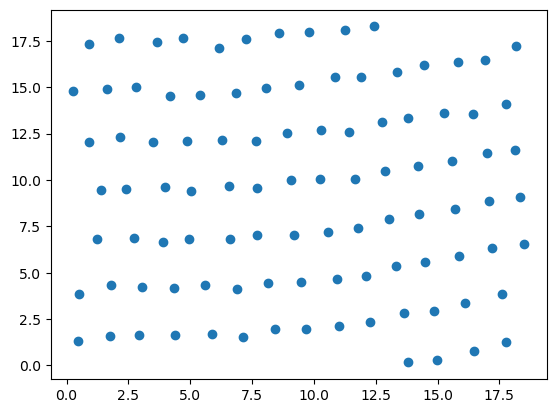

In [10]:
density = 0.291
n_pre = 2000000
n_equ = 2000000
n_prod = 20000000
n_particels = 100
cold_start = Particles_2D(o=0.291,N=n_particels,delta_step=2)
cold_start.run_mc(max_iter=n_pre,T=100.0,hotstart=True) 
with open('runs/cold_start_0291.pkl', 'wb') as file:
    pickle.dump(cold_start, file)
particels = cold_start

for t in [0.25,0.24,0.23,0.22,0.21,0.20,0.19,0.18,0.17,0.16,0.15]:
    # create new folder
    # with open('runs/cold_start_0291.pkl', 'rb') as file:
    #     particels = pickle.load(file)
    dir_equ = f"runs/equilibrium/run_equ_{density}_{t}.pkl"
    dir_prod =  f"runs/production/run_prod_{density}_{t}.pkl"
    print(f"Starting equilibrium run at Temperature {t}")
    particels.run_mc(max_iter=n_equ,T=t,cal_delta=True,block_size=100)
    with open(dir_equ, 'wb') as file:
        pickle.dump(particels, file)
    plt.figure()
    plt.scatter(particels.con[:,0],particels.con[:,1])
    plt.show()
    

    print(f"Starting production run at Temperature {t}")
    particels.run_mc(max_iter=n_prod,T=t,prod=True)
    with open(dir_prod, 'wb') as file:
        pickle.dump(particels, file)
    plt.figure()
    plt.scatter(particels.con[:,0],particels.con[:,1])
    plt.show()
    

    

## Energy plots and Variance

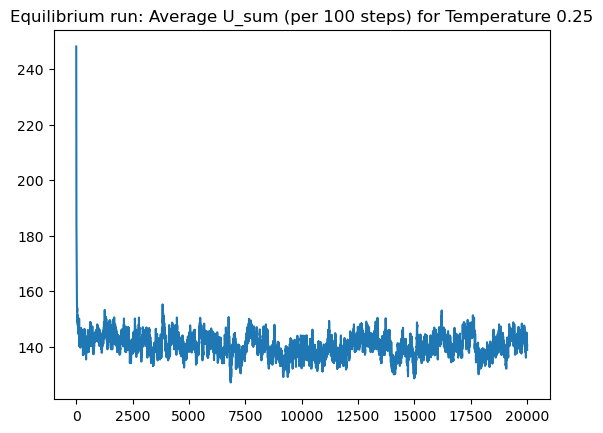

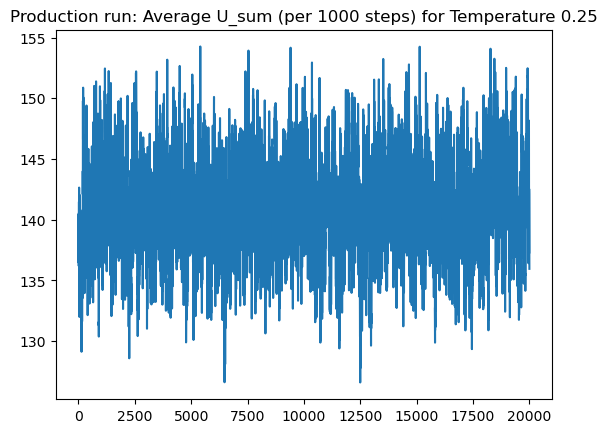

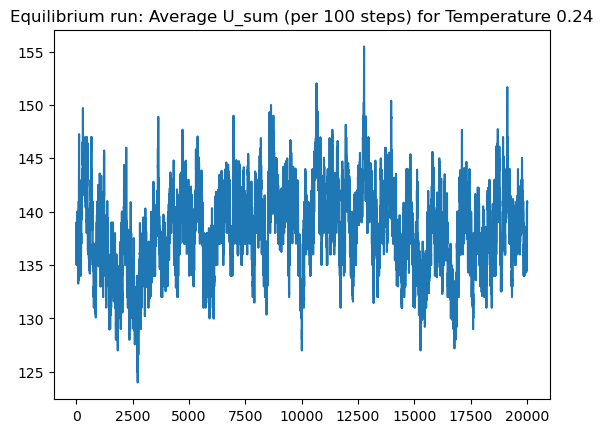

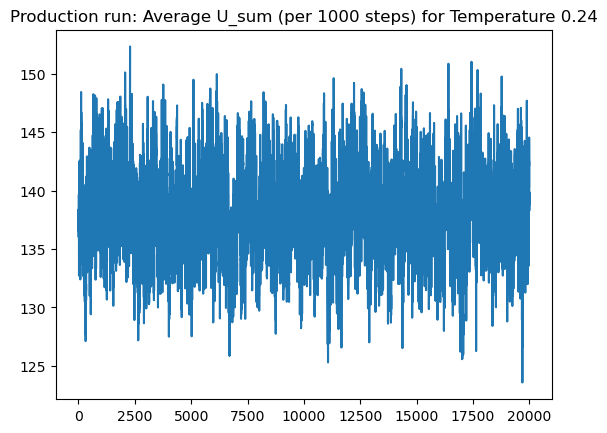

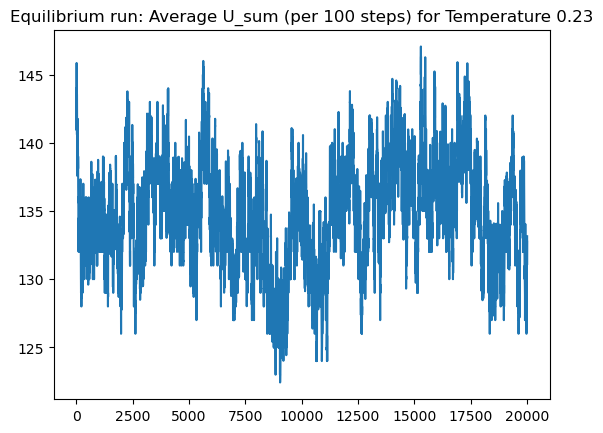

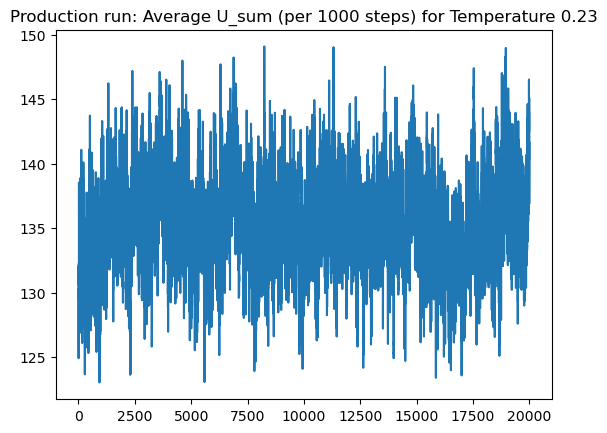

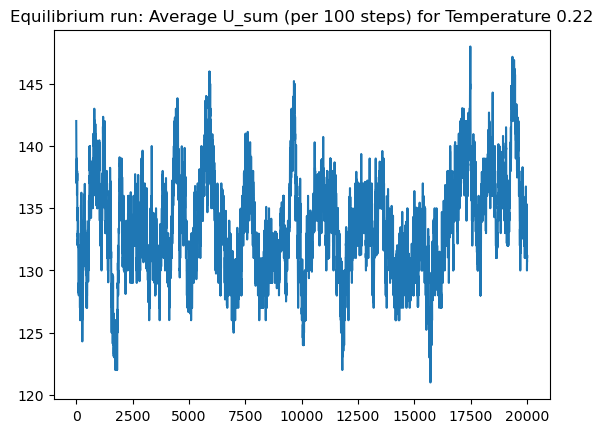

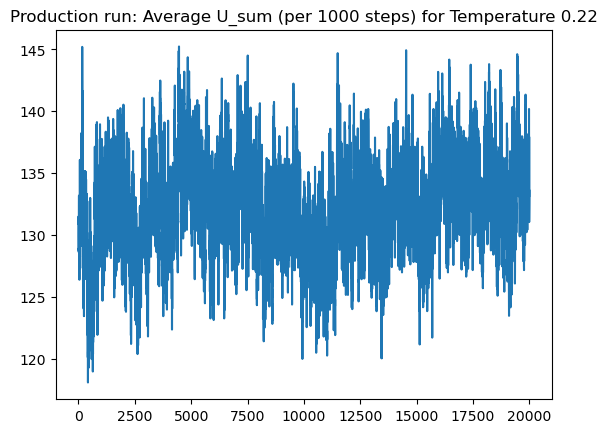

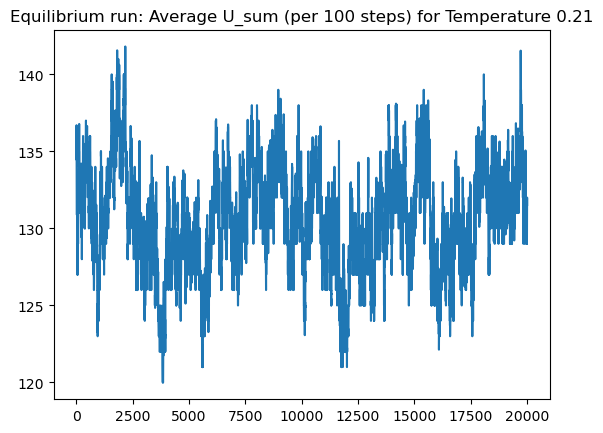

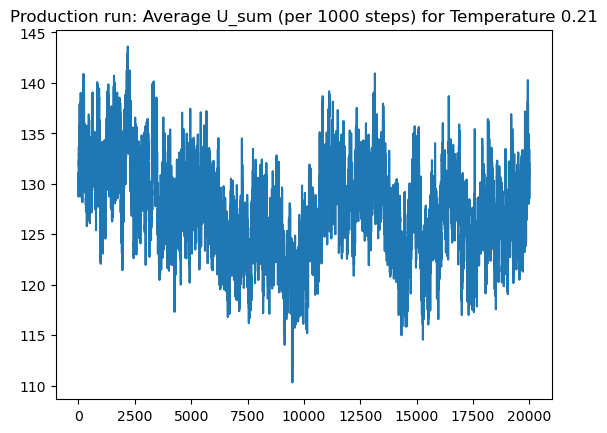

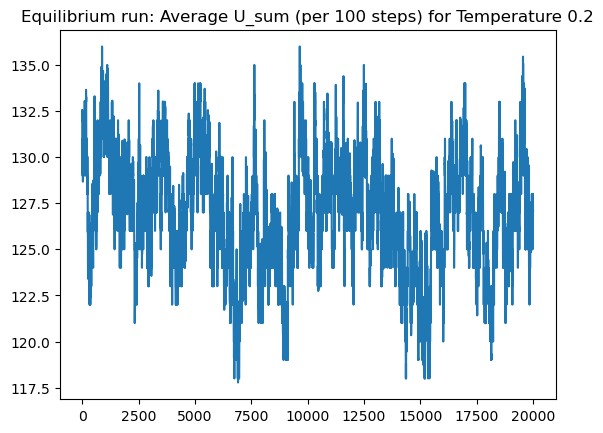

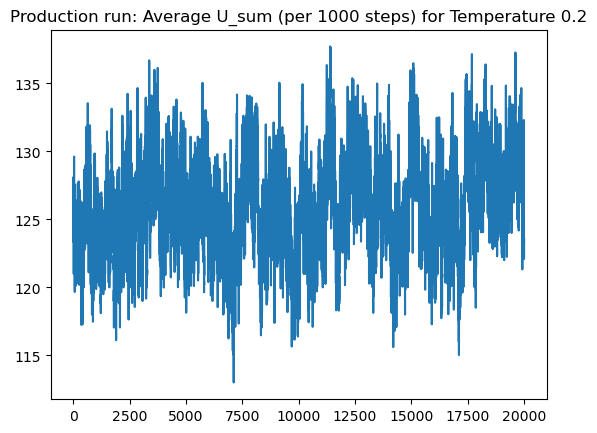

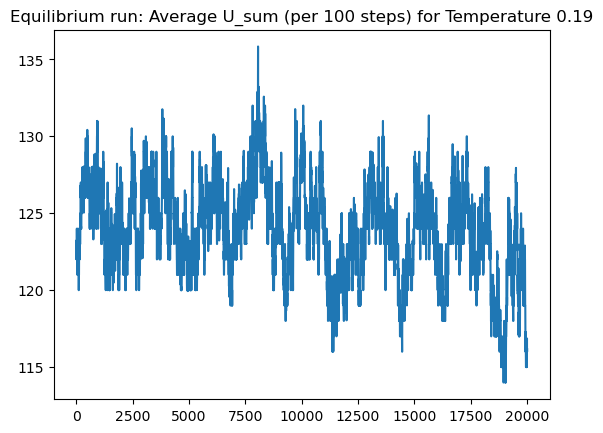

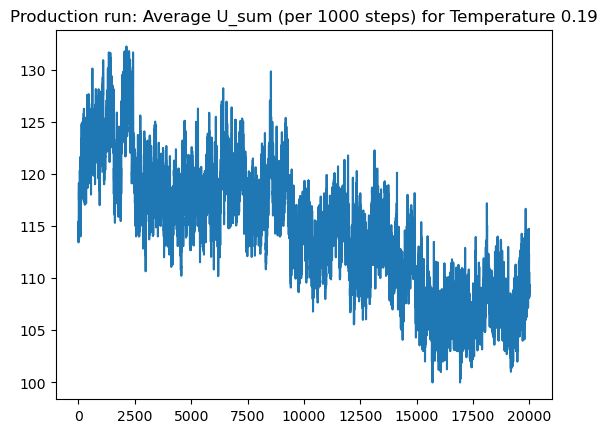

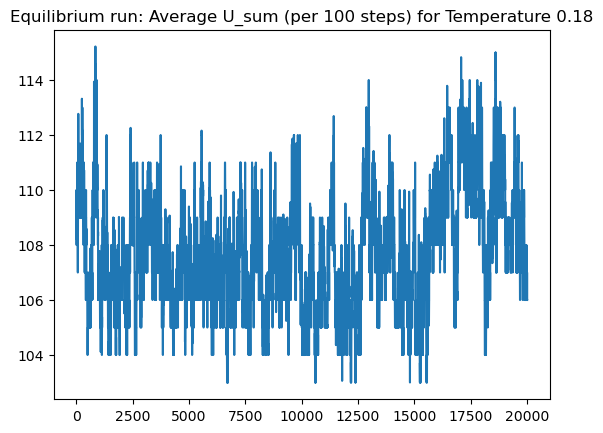

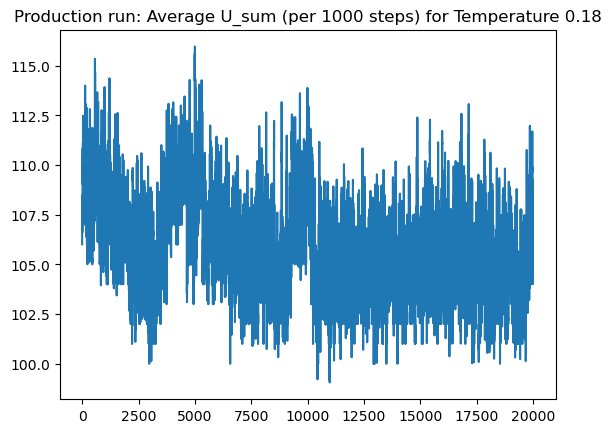

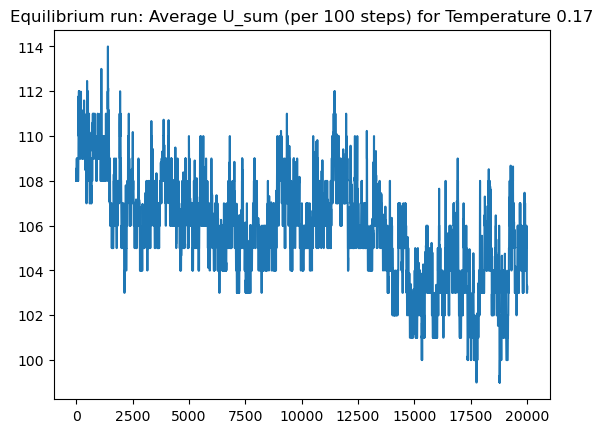

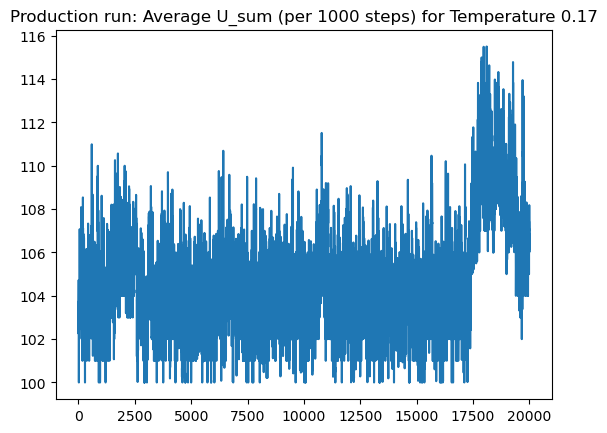

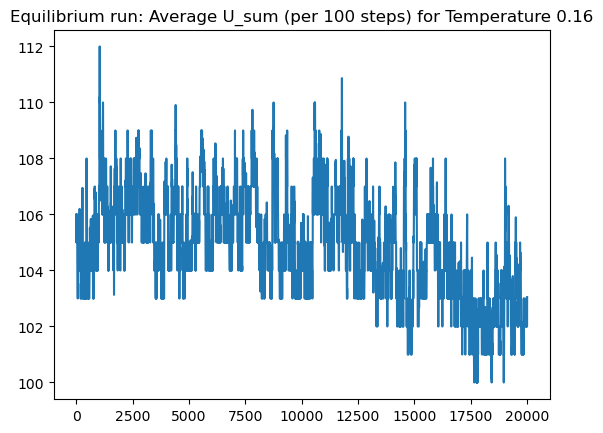

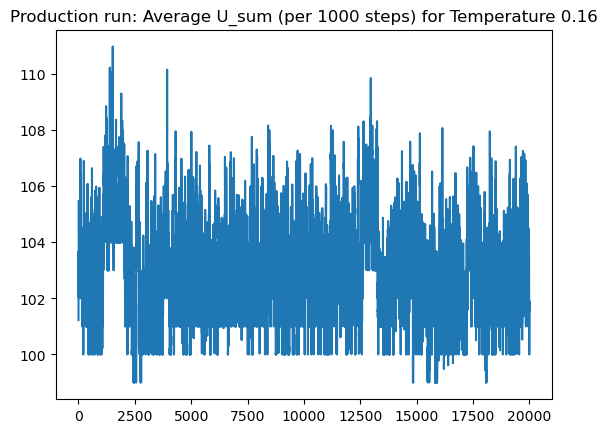

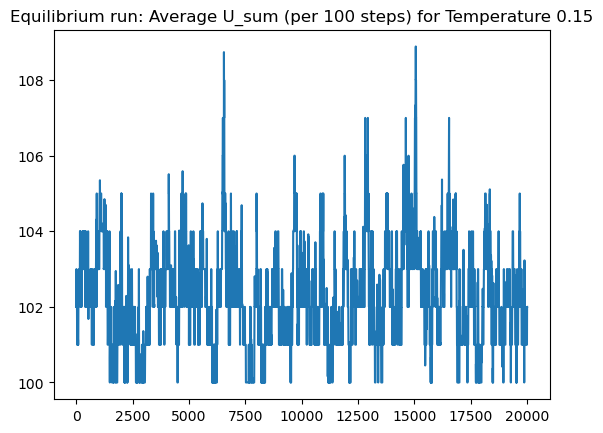

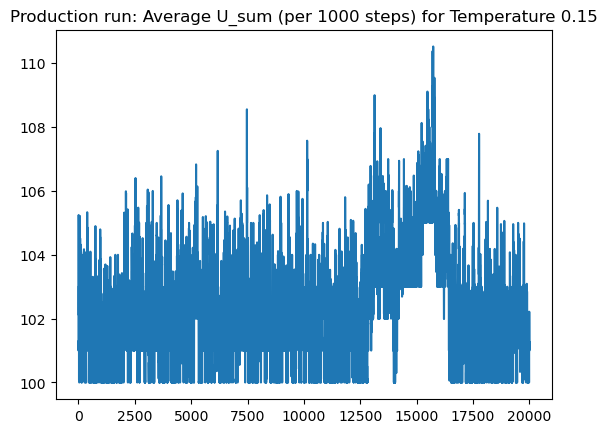

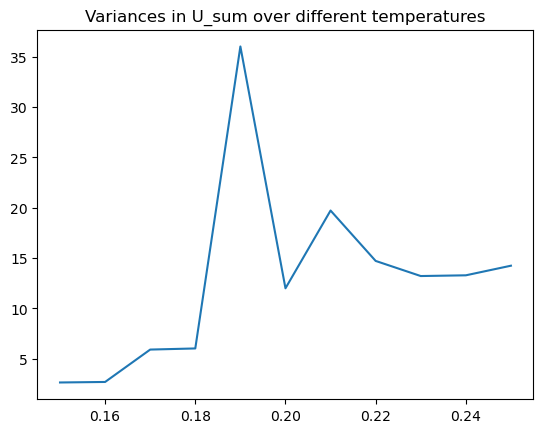

In [14]:
variances = []
temperatures = [0.25,0.24,0.23,0.22,0.21,0.20,0.19,0.18,0.17,0.16,0.15]
for t in temperatures:
    # create new folder
    # with open('runs/cold_start_0291.pkl', 'rb') as file:
    #     particels = pickle.load(file)
    dir_equ = f"runs/equilibrium/run_equ_{density}_{t}.pkl"
    dir_prod =  f"runs/production/run_prod_{density}_{t}.pkl"


    with open(dir_equ, 'rb') as file:
        particels = pickle.load(file)
    plt.figure()
    plt.plot(range(len(particels.block_averages)),particels.block_averages)
    plt.title(f"Equilibrium run: Average U_sum (per 100 steps) for Temperature {t}")
    plt.show()

    with open(dir_prod, 'rb') as file:
        particels = pickle.load(file)
    plt.figure()
    plt.plot(range(len(particels.block_averages)),particels.block_averages)
    plt.title(f"Production run: Average U_sum (per 1000 steps) for Temperature {t}")
    plt.show()

    block_averages, variance_blocks = particels.average_sum()
    variances.append(variance_blocks)

plt.figure()
plt.plot(temperatures,variances)
plt.title(f"Variances in U_sum over different temperatures")
plt.show()

    
    


        